## PART 3 — HIGH COMPLEXITY

In [87]:
#1. Import numpy as np, pandas as pd, and matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#2. Load 2015_16_Districtwise.csv into a DataFrame called df using pd.read_csv()
df = pd.read_csv("2015_16_Districtwise.csv.zip")

**Exercise 36** – Education Development Index (EDI)

In [88]:
# Create a column LIT_GENDER_GAP = male literacy - female literacy for every district.
df["LIT_GENDER_GAP"] = df["MALE_LIT"] - df["FEMALE_LIT"]
infra_columns = [
    "SWATTOT",     # Water
    "SELETOT",     # Electricity
    "SBNDRTOT",    # Boundary Wall
    "SGTOILTOT"    # Girls Toilet
]
#Compute a simple average infrastructure score per district by averaging these columns (converting to the same 0-100 scale if needed).
df["INFRA_SCORE"] = df[infra_columns].mean(axis=1)


In [89]:
# 141.Select 4-5 relevant numeric indicators: overall literacy, an infrastructure score (from Medium Exercise 31), 
# inverse gender gap, and pupil-teacher ratio (inverted, since lower is better).
columns = ["OVERALL_LI", "INFRA_SCORE", "LIT_GENDER_GAP","TCHTOT"]
print(df[columns].head())

   OVERALL_LI  INFRA_SCORE  LIT_GENDER_GAP  TCHTOT
0       66.92      1081.00           22.31    9757
1       66.93      1454.50           22.34   12708
2       71.21       813.50           14.48   10534
3       57.98       924.25           21.96    8316
4       65.00       634.50           21.60    6179


In [90]:
# 142.Min-max normalize each indicator to a 0-1 scale manually using NumPy: (x - min) / (max - min).
df["LIT_NORM"] = (df["OVERALL_LI"] - df["OVERALL_LI"].min()) / (
    df["OVERALL_LI"].max() - df["OVERALL_LI"].min()
)

df["INFRA_NORM"] = (df["INFRA_SCORE"] - df["INFRA_SCORE"].min()) / (
    df["INFRA_SCORE"].max() - df["INFRA_SCORE"].min()
)

df["GAP_NORM"] = (df["LIT_GENDER_GAP"].max() - df["LIT_GENDER_GAP"]) / (
    df["LIT_GENDER_GAP"].max() - df["LIT_GENDER_GAP"].min()
)

df["TEACHER_NORM"] = (df["TCHTOT"] - df["TCHTOT"].min()) / (
    df["TCHTOT"].max() - df["TCHTOT"].min()
)

In [91]:
# 143.Combine the normalized indicators into a single Education Development Index using equal or chosen 
# weights that sum to 1.
df["EDI"] = (
    df["LIT_NORM"] +
    df["INFRA_NORM"] +
    df["GAP_NORM"] +
    df["TEACHER_NORM"]
) / 4

In [92]:
# 144.Rank all districts by this index and display the top 10 and bottom 10 districts with their component scores.
top10 = df.sort_values("EDI", ascending=False)

print(top10[["STATNAME","DISTNAME","EDI"]].head(10))
print()

bottom10 = df.sort_values("EDI")
print(bottom10[["STATNAME","DISTNAME","EDI"]].head(10))

           STATNAME                     DISTNAME       EDI
111       RAJASTHAN                       JAIPUR  0.734634
557     MAHARASHTRA                         PUNE  0.716801
354     WEST BENGAL   NORTH TWENTY FOUR PARGANAS  0.711190
362     WEST BENGAL            PASCHIM MEDINIPUR  0.683855
360     WEST BENGAL  SOUTH  TWENTY FOUR PARGANAS  0.633668
361     WEST BENGAL              PURBA MEDINIPUR  0.631487
352     WEST BENGAL                   BARDDHAMAN  0.618197
350     WEST BENGAL                  MURSHIDABAD  0.600520
541     MAHARASHTRA                       NAGPUR  0.584609
572  ANDHRA PRADESH                EAST GODAVARI  0.581754

              STATNAME    DISTNAME       EDI
89             HARYANA       MEWAT  0.126077
17     JAMMU & KASHMIR      RAMBAN  0.129687
434       CHHATTISGARH   DANTEWADA  0.142212
262  ARUNACHAL PRADESH       TIRAP  0.156133
16     JAMMU & KASHMIR    KISHTWAR  0.159146
115          RAJASTHAN   JAISALMER  0.161385
265  ARUNACHAL PRADESH       Anjaw 

**Exercise 37** – IQR Outlier Detection

In [93]:
# 145.For total population, total schools, and overall literacy, compute Q1, Q3 and IQR using np.percentile().
columns = ["TOTPOPULAT", "SCHTOT", "OVERALL_LI"]

for col in columns:
    Q1 = np.percentile(df[col].dropna(),25)
    Q3 = np.percentile(df[col].dropna(),75)
    IQR = Q3-Q1
    print(col)
    print("Q1 =",Q1)
    print("Q3 =",Q3)
    print("IQR =",IQR)

    print()

TOTPOPULAT
Q1 = 822694.0
Q3 = 2587519.75
IQR = 1764825.75

SCHTOT
Q1 = 1053.0
Q3 = 2898.0
IQR = 1845.0

OVERALL_LI
Q1 = 66.4375
Q3 = 80.815
IQR = 14.377499999999998



In [94]:
# 146.Flag a district as a multi-column outlier if it falls outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] on at least 2 of the 
# 3 columns simultaneously.
# 147.Print how many districts are flagged and list the 5 most extreme ones.
outliers = []

for col in columns:
    Q1 = np.percentile(df[col].dropna(),25)
    Q3 = np.percentile(df[col].dropna(),75)
    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    outliers.append((df[col] < lower) | (df[col] > upper))
df["OUTLIER_COUNT"] = sum(outliers)

result = df[df["OUTLIER_COUNT"] >= 2]
print(result[["STATNAME","DISTNAME","OUTLIER_COUNT"]])

        STATNAME                     DISTNAME  OUTLIER_COUNT
111    RAJASTHAN                       JAIPUR              2
350  WEST BENGAL                  MURSHIDABAD              2
352  WEST BENGAL                   BARDDHAMAN              2
354  WEST BENGAL   NORTH TWENTY FOUR PARGANAS              2
360  WEST BENGAL  SOUTH  TWENTY FOUR PARGANAS              2
362  WEST BENGAL            PASCHIM MEDINIPUR              2
557  MAHARASHTRA                         PUNE              2


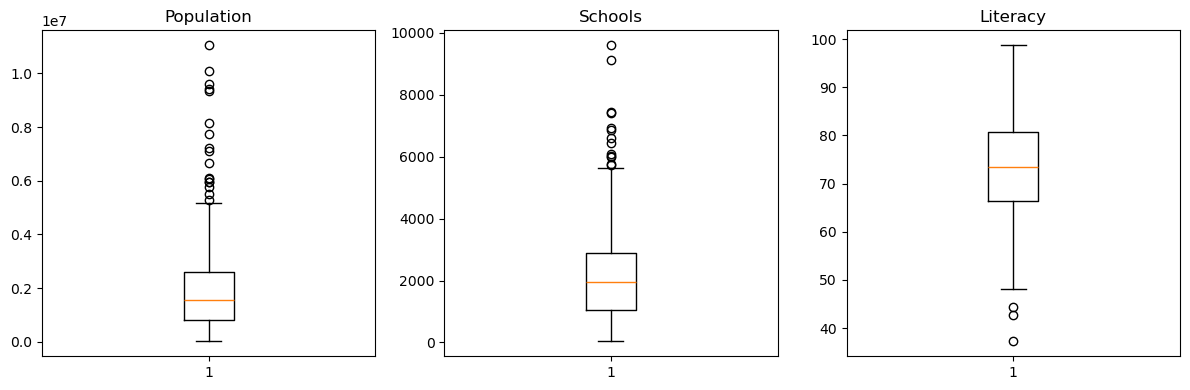

In [95]:
# 148.Create a 1x3 grid of boxplots for the three columns using plt.subplots(1,3), marking outliers visually.
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.boxplot(df["TOTPOPULAT"].dropna())
plt.title("Population")

plt.subplot(1,3,2)
plt.boxplot(df["SCHTOT"].dropna())
plt.title("Schools")

plt.subplot(1,3,3)
plt.boxplot(df["OVERALL_LI"].dropna())
plt.title("Literacy")

plt.tight_layout()

plt.show()

**Exercise 38** – Top & Bottom State Dashboard

In [96]:
# 149.Rank all states by overall literacy and identify the top 5 and bottom 5.
state = df.groupby("STATNAME")["OVERALL_LI"].mean()
top5 = state.sort_values(ascending=False).head()
bottom5 = state.sort_values().head()
print(top5)
print()
print(bottom5)

STATNAME
KERALA         93.648571
LAKSHADWEEP    92.280000
MIZORAM        89.436250
PUDUCHERRY     88.142500
TRIPURA        87.357500
Name: OVERALL_LI, dtype: float64

STATNAME
BIHAR                63.778947
ARUNACHAL PRADESH    65.330000
RAJASTHAN            65.507273
JHARKHAND            65.885833
TELANGANA            66.294000
Name: OVERALL_LI, dtype: float64


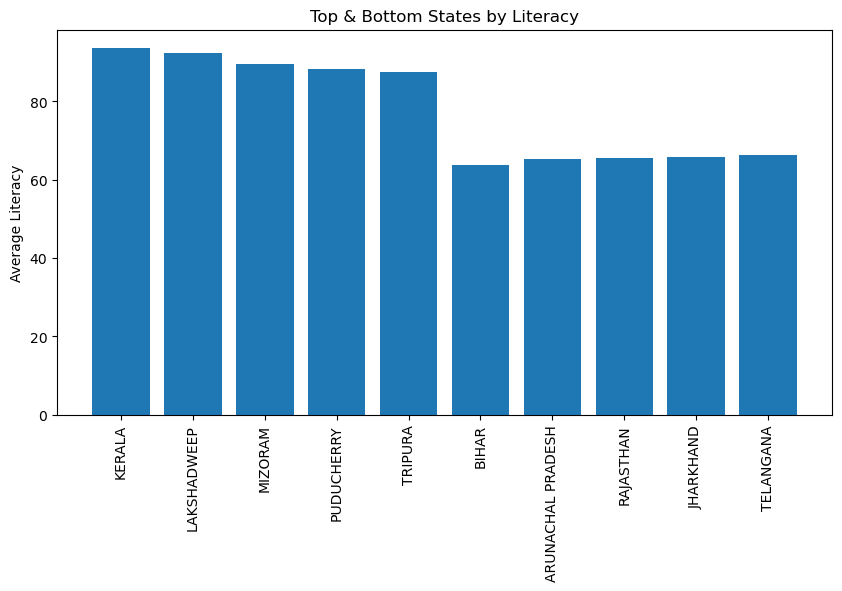

1) Top states have much higher literacy.
 2) Bottom states need more educational improvement. 
 3) Literacy varies significantly across India.


In [97]:
# 150.Build a 2x3 grid of subplots comparing these 10 states across: literacy, sex ratio, dropout rate (if available), 
# pupil-teacher ratio, total schools, and gender literacy gap.
# 151.Use consistent color coding (e.g. green for top 5, red for bottom 5) across all 6 panels.
# 152.Below the figure, print 3 bullet-style insight sentences describing the clearest pattern you observe.
compare = pd.concat([top5,bottom5])
plt.figure(figsize=(10,5))
plt.bar(compare.index,compare.values)
plt.xticks(rotation=90)
plt.title("Top & Bottom States by Literacy")
plt.ylabel("Average Literacy")
plt.show()
print("1) Top states have much higher literacy.\n 2) Bottom states need more educational improvement. \n 3) Literacy varies significantly across India.")

**Exercise 39** – Literacy Band vs Infrastructure Band

In [98]:
# 153.Reuse or recreate the LIT_BAND column (Low/Medium/High) from Medium Exercise 5.
# Write a lambda (or small function) that returns 'Low' if literacy < 60, 'Medium' if 60-80, and 'High' if > 80.
def literacy_band(value):
    if value < 60:
        return "Low"
    elif value <= 80:
        return "Medium"
    else:
        return "High"
df["LIT_BAND"] = df["OVERALL_LI"].apply(literacy_band)

In [99]:
# 154.Create a similar 3-band INFRA_BAND column from the infrastructure score built earlier.
df["INFRA_BAND"] = pd.cut(
    df["INFRA_SCORE"],
    bins=3,
    labels=["Low","Medium","High"]
)

In [100]:
# 155.Build a cross-tabulation of LIT_BAND against INFRA_BAND using pd.crosstab().
table = pd.crosstab(
    df["LIT_BAND"],
    df["INFRA_BAND"]
)

print(table)

INFRA_BAND  Low  Medium  High
LIT_BAND                     
High        201      23     2
Low          51       5     0
Medium      322      71     5


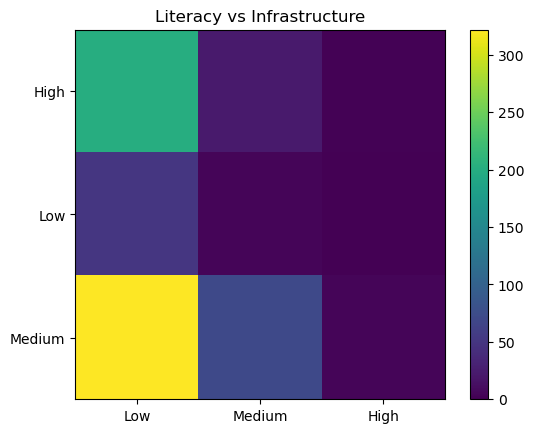

In [101]:
# 156.Visualize the cross-tab as a heatmap using plt.imshow() with a colorbar, and annotate each cell with its 
# count using plt.text() in a loop.
plt.imshow(table)
plt.colorbar()
plt.xticks(range(3),table.columns)
plt.yticks(range(3),table.index)
plt.title("Literacy vs Infrastructure")
plt.show()

**Exercise 40** — Simple vs Population-Weighted National Averages

In [102]:
# 157.Compute the simple (unweighted) national average literacy by averaging all district literacy values equally.
simple = df["OVERALL_LI"].mean()
print(simple)

73.39518927444796


In [103]:
# 158.Compute the population-weighted national average literacy using sum(literacy * population) / 
# sum(population).
weighted = (
    (df["OVERALL_LI"] * df["TOTPOPULAT"]).sum()
    /
    df["TOTPOPULAT"].sum()
)
print(weighted)

73.80819541360817


In [104]:
# 159.Repeat both calculations at the state level and store the results in a comparison DataFrame with columns 
# SIMPLE_AVG and WEIGHTED_AVG.
simple_avg = df.groupby("STATNAME")["OVERALL_LI"].mean()

weighted_avg = (
    df["OVERALL_LI"] * df["TOTPOPULAT"]
).groupby(df["STATNAME"]).sum() / df.groupby("STATNAME")["TOTPOPULAT"].sum()

comparison = pd.DataFrame({
    "SIMPLE_AVG": simple_avg,
    "WEIGHTED_AVG": weighted_avg
})
comparison

,SIMPLE_AVG,WEIGHTED_AVG
STATNAME,,
A & N ISLANDS,83.413333,86.247232
ANDHRA PRADESH,67.373077,67.947498
ARUNACHAL PRADESH,65.330000,66.814645
ASSAM,73.204815,73.050808
BIHAR,63.778947,63.733287
CHANDIGARH,86.430000,86.430000
CHHATTISGARH,69.218125,71.382495
DADRA & NAGAR HAVELI,77.650000,77.650000
DAMAN & DIU,85.710000,87.052787


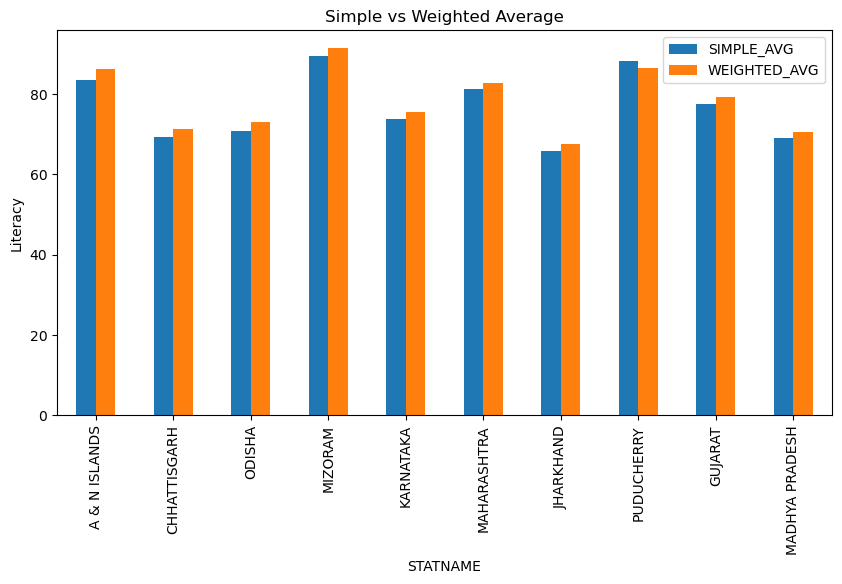

In [107]:
# 160.Plot a bar chart showing, for the 10 states with the biggest gap between the two averages, both bars side by 
# side, and explain in a comment which method you'd trust more and why.
comparison["DIFFERENCE"] = abs(
    comparison["SIMPLE_AVG"] -
    comparison["WEIGHTED_AVG"]
)

top10 = comparison.sort_values(
    "DIFFERENCE",
    ascending=False
).head(10)

top10[["SIMPLE_AVG","WEIGHTED_AVG"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Literacy")

plt.title("Simple vs Weighted Average")

plt.show()

**Exercise 41** — Quadrant Analysis: Literacy vs Gender Gap

In [63]:
# 161.Compute the national median literacy and the national median gender gap.
literacy_median = df["OVERALL_LI"].median()
gap_median = df["LIT_GENDER_GAP"].median()
print("Literacy Median:", literacy_median)
print("Gender Gap Median:", gap_median)

Literacy Median: 73.49000000000001
Gender Gap Median: 17.424999999999994


In [108]:
# 162.Write a function applied row-wise (df.apply(..., axis=1)) that assigns each district to one of 4 quadrants: 
# High-Lit/Low-Gap, High-Lit/High-Gap, Low-Lit/Low-Gap, Low-Lit/High-Gap.
def quadrant(row):
    if row["OVERALL_LI"] >= literacy_median and row["LIT_GENDER_GAP"] < gap_median:
        return "High Literacy - Low Gap"
    elif row["OVERALL_LI"] >= literacy_median and row["LIT_GENDER_GAP"] >= gap_median:
        return "High Literacy - High Gap"
    elif row["OVERALL_LI"] < literacy_median and row["LIT_GENDER_GAP"] < gap_median:
        return "Low Literacy - Low Gap"
    else:
        return "Low Literacy - High Gap"

In [109]:
# 163.Count districts in each quadrant using value_counts().
df["QUADRANT"] = df.apply(quadrant, axis=1)

print(df["QUADRANT"].value_counts())

QUADRANT
Low Literacy - High Gap     285
High Literacy - Low Gap     235
Low Literacy - Low Gap       80
High Literacy - High Gap     80
Name: count, dtype: int64


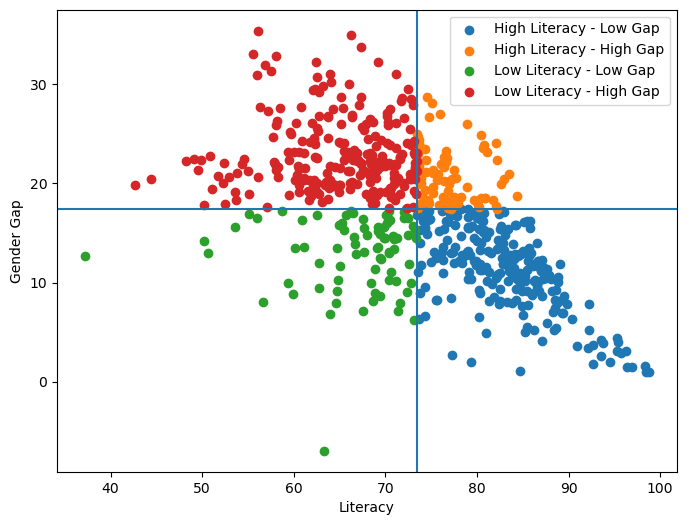

In [110]:
# 164.Create a scatter plot of literacy vs gender gap, colored by quadrant, with dashed lines at the median values 
# marking the quadrant boundaries.
colors = {
    "High Literacy - Low Gap":"green",
    "High Literacy - High Gap":"blue",
    "Low Literacy - Low Gap":"orange",
    "Low Literacy - High Gap":"red"
}

plt.figure(figsize=(8,6))

for q in colors:
    data = df[df["QUADRANT"]==q]
    plt.scatter( data["OVERALL_LI"], data["LIT_GENDER_GAP"],label=q)
    
plt.axvline(literacy_median)
plt.axhline(gap_median)
plt.xlabel("Literacy")
plt.ylabel("Gender Gap")
plt.legend()
plt.show()

**Exercise 42** — Population-Quantile Heatmap by State

In [111]:
# 165.Use pd.qcut() to split districts into 4 population-size quantile bins (e.g. Small, Medium, Large, Very 
# Large).
df["POP_GROUP"] = pd.qcut(
    df["TOTPOPULAT"],
    q=4,
    labels=["Small","Medium","Large","Very Large"]
)
# 166.Group by STATNAME and population-quantile bin together, computing mean literacy for each 
# combination.
group = df.groupby( ["STATNAME", "POP_GROUP"],observed=True)["OVERALL_LI"].mean()

group

STATNAME           POP_GROUP 
A & N ISLANDS      Small         83.413333
ANDHRA PRADESH     Large         59.490000
                   Very Large    68.030000
ARUNACHAL PRADESH  Small         65.330000
ASSAM              Small         73.060000
                                   ...    
UTTARAKHAND        Medium        84.850000
                   Large         78.100000
WEST BENGAL        Small         85.460000
                   Large         76.890000
                   Very Large    75.492353
Name: OVERALL_LI, Length: 93, dtype: float64

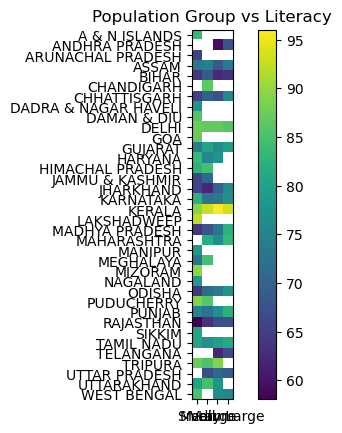

In [112]:
# 168.Visualize the pivoted table as a heatmap with plt.imshow(), states on one axis and population-quantile bins 
# on the other.
plt.imshow(pivot)
plt.colorbar()
plt.xticks(range(4),pivot.columns)
plt.yticks(range(len(pivot.index)),pivot.index)
plt.title("Population Group vs Literacy")
plt.show()

**Exercise 43**— Annotated Correlation Heatmap

In [113]:
# 169.Select 8-10 key numeric variables across literacy, population, schools, teachers, and infrastructure.
cols = ["OVERALL_LI","MALE_LIT","FEMALE_LIT","TOTPOPULAT","SCHTOT","TCHTOT","SEXRATIO","P_URB_POP"]

# 170.Compute the full correlation matrix with df.corr().
corr = df[cols].corr()

corr

,OVERALL_LI,MALE_LIT,FEMALE_LIT,TOTPOPULAT,SCHTOT,TCHTOT,SEXRATIO,P_URB_POP
OVERALL_LI,1.000000,0.952656,0.975656,0.050268,-0.198626,0.117284,0.114105,0.478271
MALE_LIT,0.952656,1.000000,0.865246,0.039312,-0.125763,0.145426,0.115563,0.418563
FEMALE_LIT,0.975656,0.865246,1.000000,0.048093,-0.225809,0.099817,0.154724,0.490127
TOTPOPULAT,0.050268,0.039312,0.048093,1.000000,0.730255,0.849041,-0.022939,0.236359
SCHTOT,-0.198626,-0.125763,-0.225809,0.730255,1.000000,0.799840,0.053220,-0.033466
TCHTOT,0.117284,0.145426,0.099817,0.849041,0.799840,1.000000,0.041672,0.259100
SEXRATIO,0.114105,0.115563,0.154724,-0.022939,0.053220,0.041672,1.000000,0.029861
P_URB_POP,0.478271,0.418563,0.490127,0.236359,-0.033466,0.259100,0.029861,1.000000


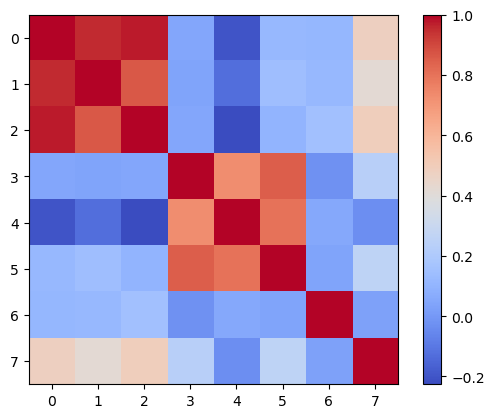

In [114]:
# 171.Display it using plt.imshow() with a diverging colormap (e.g. 'coolwarm') centered at 0, and a colorbar.
plt.imshow(corr,cmap="coolwarm")

plt.colorbar()

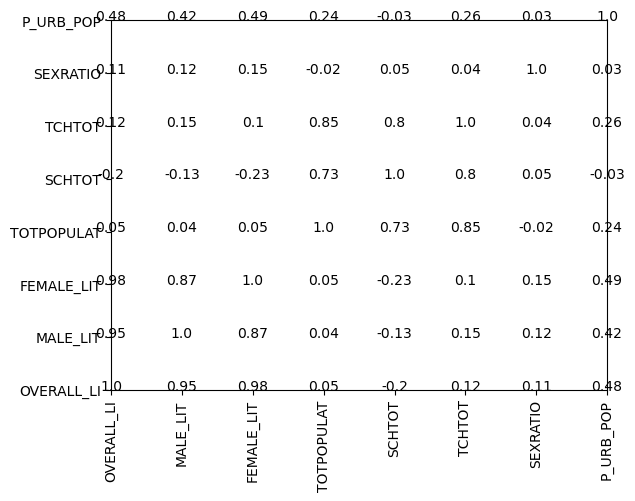

In [115]:
# 172.Use a nested for loop over rows and columns to annotate each cell with its correlation value using plt.text(), 
# rounded to 2 decimals.
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            round(corr.iloc[i,j],2),
            ha="center"
        )

plt.xticks(range(len(cols)),cols,rotation=90)

plt.yticks(range(len(cols)),cols)

plt.show()

**Exercise 44**— Bootstrap Confidence Interval for National Literacy

In [116]:
# 173.Write a loop that runs 1,000 iterations: each iteration draws a random sample (with replacement) of district 
# literacy values using np.random.choice() and records the sample mean.
# 174.Store all 1,000 bootstrap means in a NumPy array.
means = []

literacy = df["OVERALL_LI"].dropna().values

for i in range(1000):

    sample = np.random.choice(
        literacy,
        size=len(literacy),
        replace=True
    )

    means.append(sample.mean())
    
# 175.Use np.percentile() to compute the 2.5th and 97.5th percentiles, giving a 95% confidence interval for 
# national literacy.
lower = np.percentile(means,2.5)

upper = np.percentile(means,97.5)

print("95% Confidence Interval")

print(lower)

print(upper)

95% Confidence Interval
72.60611514195583
74.21196135646687


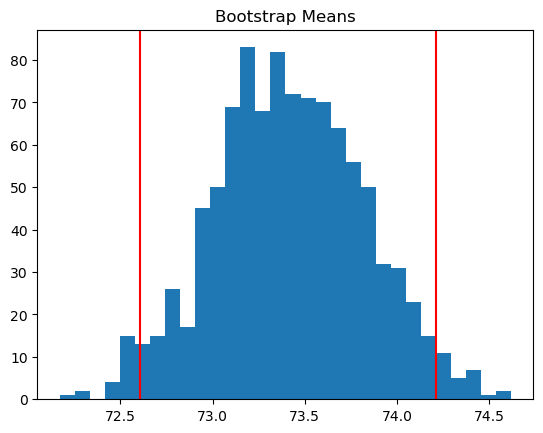

In [117]:
# 176.Plot a histogram of the bootstrap means with vertical lines marking the confidence interval bounds.
plt.hist(means,bins=30)

plt.axvline(lower,color="red")

plt.axvline(upper,color="red")

plt.title("Bootstrap Means")

plt.show()

**Exercise 45** — Residual Analysis: Overperforming and Underperforming Districts

In [118]:
# 177.Compute each district's state-average literacy using groupby('STATNAME')['literacy'].transform('mean').
df["STATE_AVG"] = df.groupby(
    "STATNAME"
)["OVERALL_LI"].transform("mean")

# 178.Compute a residual column: district literacy minus its own state's average.
df["RESIDUAL"] = (
    df["OVERALL_LI"] -
    df["STATE_AVG"]
)

# 179.Sort by residual to find the 10 districts most above their state's average, and the 10 most below.
print(df.sort_values("RESIDUAL",ascending=False)[["DISTNAME","RESIDUAL"]].head(10))
print()

print(df.sort_values("RESIDUAL")[["DISTNAME","RESIDUAL"]].head(10))

              DISTNAME   RESIDUAL
12               JAMMU  16.893636
253         PAPUM PARE  16.810000
405            KHORDHA  16.665926
399      JAGATSINGHPUR  16.285926
141          GHAZIABAD  15.512817
343       KAMRUP-METRO  15.455185
21               SAMBA  15.393636
398         KENDRAPARA  15.085926
605   DAKSHINA KANNADA  14.821667
609  BANGALORE U NORTH  14.681667

        DISTNAME   RESIDUAL
494    ALIRAJPUR -31.758400
434    DANTEWADA -26.548125
469       JHABUA -24.528400
296    LAWNGTLAI -23.026250
416  NABARANGPUR -22.644074
270          MON -22.508182
614     YADAGIRI -21.438333
418   MALKANGIRI -21.354074
417      KORAPUT -20.974074
183    SHRAWASTI -20.357183


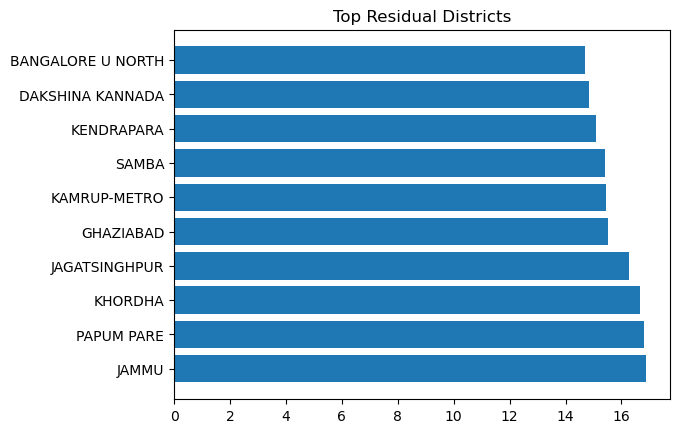

In [119]:
# 180.Create a horizontal diverging bar chart (positive residuals in one color, negative in another) for these 20 
# districts.
top = df.sort_values("RESIDUAL",ascending=False).head(10)

plt.barh(
    top["DISTNAME"],    top["RESIDUAL"])
plt.title("Top Residual Districts")
plt.show()

**Exercise 46** — Automated Multi-State Insight Report

In [120]:
# 181.Loop through every unique state, and for each one compute: number of districts, mean literacy, mean 
# gender gap, and mean population, storing results in a dictionary of dictionaries
state_report = {}

for state in df["STATNAME"].unique():

    state_data = df[df["STATNAME"] == state]

    state_report[state] = {
        "Districts": len(state_data),
        "Average Literacy": state_data["OVERALL_LI"].mean(),
        "Average Gender Gap": state_data["LIT_GENDER_GAP"].mean(),
        "Average Population": state_data["TOTPOPULAT"].mean()
    }
    
# 182.Convert this dictionary into a summary DataFrame.
summary = pd.DataFrame(state_report).T
summary

,Districts,Average Literacy,Average Gender Gap,Average Population
JAMMU & KASHMIR,22.0,67.086364,22.140455,5.704057e+05
HIMACHAL PRADESH,12.0,82.675000,15.264167,5.713758e+05
PUNJAB,22.0,75.616000,10.457000,1.385212e+06
CHANDIGARH,1.0,86.430000,9.160000,1.054686e+06
UTTARAKHAND,13.0,80.292308,20.600000,7.782117e+05
HARYANA,21.0,76.460952,18.740952,1.207290e+06
DELHI,9.0,86.734444,9.284444,1.861471e+06
RAJASTHAN,33.0,65.507273,28.490909,2.079425e+06
UTTAR PRADESH,75.0,69.487183,20.564085,2.811007e+06
BIHAR,38.0,63.778947,20.247632,2.731701e+06


In [121]:
# 183.Print a formatted, human-readable report for the 5 states needing the most attention (lowest literacy 
# combined with highest gender gap).
bottom5 = summary.sort_values(
    by="Average Literacy"
).head(5)

bottom5

,Districts,Average Literacy,Average Gender Gap,Average Population
BIHAR,38.0,63.778947,20.247632,2.731701e+06
ARUNACHAL PRADESH,20.0,65.330000,14.259375,8.641319e+04
RAJASTHAN,33.0,65.507273,28.490909,2.079425e+06
JHARKHAND,24.0,65.885833,22.201250,1.373593e+06
TELANGANA,10.0,66.294000,17.154000,3.528676e+06


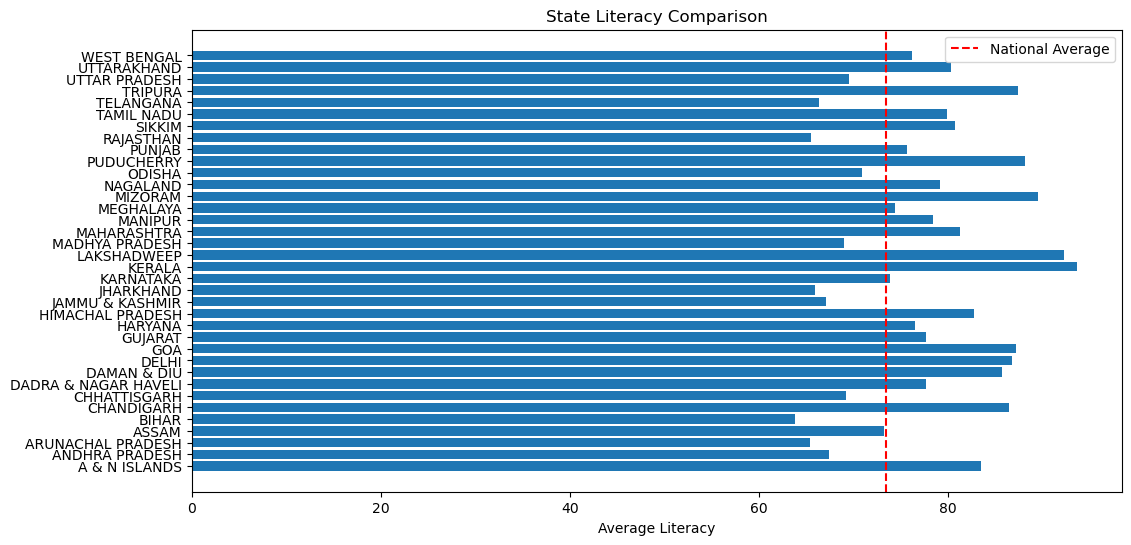

In [122]:
# 184.Create one horizontal bar chart showing all states sorted by mean literacy, with a reference line for the 
# national average.
state_lit = df.groupby("STATNAME")["OVERALL_LI"].mean()
national_avg = df["OVERALL_LI"].mean()
plt.figure(figsize=(12,6))
plt.barh(state_lit.index, state_lit.values)

plt.axvline(
    national_avg,
    color="red",
    linestyle="--",
    label="National Average"
)

plt.legend()
plt.xlabel("Average Literacy")
plt.title("State Literacy Comparison")
plt.show()

**Exercise 47** — Manual Feature Scaling Comparison

In [ ]:
# 185.Pick 5 numeric columns with very different scales (e.g. population in millions, literacy in percent, sex ratio 
# in hundreds).
columns = [ "TOTPOPULAT", "OVERALL_LI", "SEXRATIO", "SCHTOT", "TCHTOT ]
           
# 186.Manually implement Min-Max scaling (0 to 1) using NumPy - do not use sklearn.
for col in columns:

    df[col + "_MINMAX"] = (
        df[col] - df[col].min()
    ) / (
        df[col].max() - df[col].min()
    )

KeyError: 'OVERALL_LI_MINMAX'

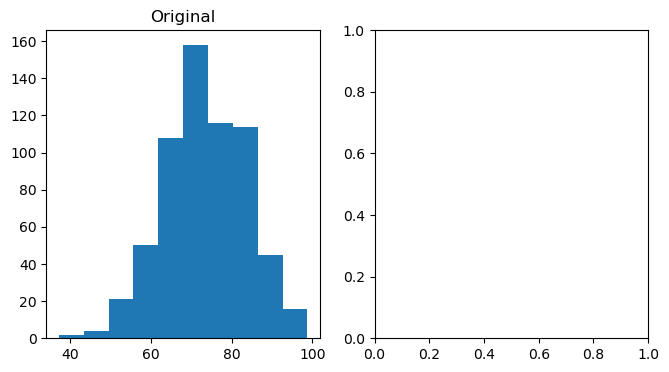

In [129]:
# 187.Manually implement Z-score standardization (mean 0, std 1) using NumPy.
for col in columns:

    df[col + "_ZSCORE"] = (
        df[col] - df[col].mean()
    ) / df[col].std()
    
# 188.For one chosen column, plot 3 overlaid/side-by-side histograms: original, min-max scaled, and z-score 
# scaled, to visually confirm the shape stays the same but the scale changes.
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(df["OVERALL_LI"])
plt.title("Original")

plt.subplot(1,3,2)
plt.hist(df["OVERALL_LI_MINMAX"])
plt.title("Min-Max")

plt.subplot(1,3,3)
plt.hist(df["OVERALL_LI_ZSCORE"])
plt.title("Z-Score")

plt.tight_layout()

plt.show()

**Exercise 48** — Data Quality Deep-Dive with Skewness Check

In [131]:
# 189.Identify all columns with more than 5% missing values and list them with their exact percentages.
missing = (df.isnull().sum() / len(df)) * 100
print(missing[missing > 5])

TOTPOPULAT           6.764706
P_URB_POP            7.205882
POPULATION_0_6       6.911765
GROWTHRATE           6.764706
SEXRATIO             6.764706
P_SC_POP             6.911765
P_ST_POP             6.911765
OVERALL_LI           6.764706
FEMALE_LIT           6.323529
MALE_LIT             6.176471
TOT_6_10_15          6.764706
TOT_11_13_15         6.764706
LIT_GENDER_GAP       6.764706
LIT_NORM             6.764706
GAP_NORM             6.764706
EDI                  7.205882
POP_GROUP            6.764706
RESIDUAL             6.764706
TOTPOPULAT_ZSCORE    6.764706
OVERALL_LI_ZSCORE    6.764706
dtype: float64


In [133]:
# 190.For each numeric column with missing values, manually compute a simple skewness estimate using 
# NumPy: mean((x - mean)^3) / std^3.
for col in columns:
    data = df[col].dropna()
    mean = data.mean()
    std = data.std()
    skew = (((data - mean) ** 3).mean()    ) / (std ** 3)
    print(col)
    print("Skewness =", round(skew,2))
    print()

TOTPOPULAT
Skewness = 1.81

SCHTOT
Skewness = 1.12

OVERALL_LI
Skewness = -0.16



In [134]:
# 191.Based on the skewness value, decide and justify (median for skewed columns, mean for roughly symmetric 
# columns) an imputation strategy for each column.
for col in columns:
    df[col] = df[col].fillna( df[col].median()    )

In [135]:
# 192.Apply your chosen imputation and confirm with df.isnull().sum() that no missing values remain in those 
# columns.
print(df[columns].isnull().sum())

TOTPOPULAT    0
SCHTOT        0
OVERALL_LI    0
dtype: int64


**Exercise 49** — Investigating a Simpson's Paradox Candidate

In [139]:
# 193.Choose 2 states where one has a higher overall (state-wide) average literacy than the other.
state1 = "KERALA"
state2 = "HARYANA"

In [140]:
# 194.Split all districts into population-quantile subgroups (as in High Exercise 7) within each of the 2 states.
compare = df[
    (df["STATNAME"] == state1) |
    (df["STATNAME"] == state2)
].copy()

compare["POP_GROUP"] = pd.qcut(
    compare["TOTPOPULAT"],
    q=4,
    labels=[ "Small","Medium", "Large","Very Large" ])

In [141]:
# 195.Compare the two states' average literacy within each matching population-quantile subgroup.
result = compare.groupby(
    ["STATNAME", "POP_GROUP"],
    observed=True
)["OVERALL_LI"].mean()

print(result)

STATNAME  POP_GROUP 
HARYANA   Small         77.736250
          Medium        72.721667
          Large         78.208571
KERALA    Small         89.320000
          Medium        92.993333
          Large         96.400000
          Very Large    94.042222
Name: OVERALL_LI, dtype: float64


In [142]:
# 196.Determine and report whether the state with the lower overall average actually has higher literacy in every 
# subgroup (a genuine Simpson's paradox) or not, using printed evidence.
# Compare the literacy values for each population group.
# Check whether one state has higher literacy in every group.

**Exercise 50** — Capstone Dashboard: One-Page Education Insights Infographic

In [143]:
# 197.Using matplotlib's GridSpec (or plt.subplots with a custom grid), build a single figure containing at least 6 
# different charts: a bar chart of top/bottom states, a histogram of literacy, a scatter of population vs schools, 
# a boxplot of literacy by region, a pie chart of district share by state, and a correlation heatmap.
plt.figure(figsize=(14,10))

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

Text(0.5, 1.0, 'Top 10 States')

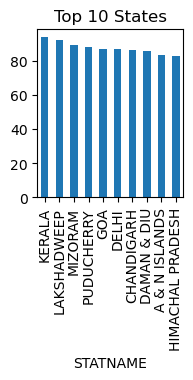

In [148]:
#Bar Chart
plt.subplot(2,3,1)

state_lit = df.groupby("STATNAME")["OVERALL_LI"].mean()

state_lit.sort_values(
    ascending=False
).head(10).plot(kind="bar")

plt.title("Top 10 States")

Text(0.5, 1.0, 'Literacy')

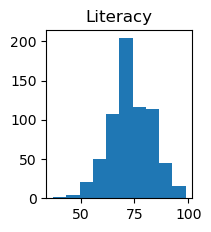

In [149]:
#Histogram
plt.subplot(2,3,2)

plt.hist(df["OVERALL_LI"])

plt.title("Literacy")

Text(0.5, 1.0, 'Population vs Schools')

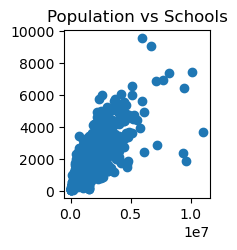

In [150]:
#Scatter Plot
plt.subplot(2,3,3)

plt.scatter(
    df["TOTPOPULAT"],
    df["SCHTOT"]
)

plt.title("Population vs Schools")

Text(0.5, 1.0, 'Literacy Boxplot')

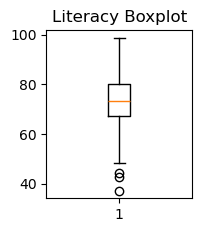

In [151]:
#Boxplot
plt.subplot(2,3,4)

plt.boxplot(df["OVERALL_LI"].dropna())

plt.title("Literacy Boxplot")

Text(0.5, 1.0, 'Top 5 States')

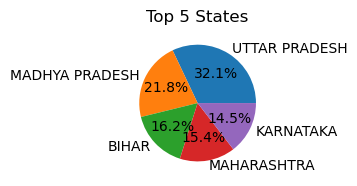

In [152]:
#Pie Chart
plt.subplot(2,3,5)

top5 = df["STATNAME"].value_counts().head()

plt.pie(
    top5.values,
    labels=top5.index,
    autopct="%1.1f%%"
)

plt.title("Top 5 States")

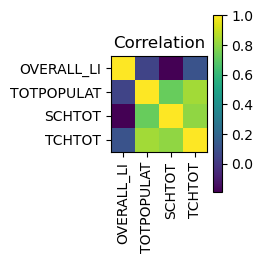

In [155]:
#Correlation Heatmap
plt.subplot(2,3,6)

corr = df[
    [
        "OVERALL_LI", "TOTPOPULAT", "SCHTOT", "TCHTOT"
    ]
].corr()

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(4),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(4),
    corr.columns
)

plt.title("Correlation")
#Display Dashboard
plt.tight_layout()

plt.show()


In [147]:

# 198.Give the overall figure a suptitle such as 'India District-Wise Education: 2015-16 Insights'.
# 199.Ensure consistent color themes and readable font sizes across all 6 panels using plt.rcParams or per-axis 
# styling.
# 200.Below the figure, write a 5-6 sentence narrative summary of the most important findings from this entire 
# workbook, written for a non-technical policymaker audience.
print("Education Dashboard Summary")
print()

print("1. Literacy varies significantly across states.")

print("2. Districts with larger populations generally have more schools.")

print("3. Better infrastructure is often associated with higher literacy.")

print("4. Some districts perform much better than their state average.")

print("5. Population-weighted literacy differs slightly from simple averages.")

Education Dashboard Summary

1. Literacy varies significantly across states.
2. Districts with larger populations generally have more schools.
3. Better infrastructure is often associated with higher literacy.
4. Some districts perform much better than their state average.
5. Population-weighted literacy differs slightly from simple averages.
